# Expfit notes

**Goal**: Fit one or multiple exponentials to (segments of) time series data, to extract time constants

**Approach**: Transform the data and use good heuristics for initial guesses, so that any optimiser will do.

## Planned functions

- [x] fit_single
- [ ] fit_double (all decaying)
- [ ] fit_triple (all decaying)
- [ ] fit_quad / fit_quadruple (all decaying)
- [ ] fit_12 (1 growing, followed by 2 decaying)
- [ ] fit_31

## Requirements on input

The method `vet_series(t, v)` checks that `t` and `v` are 1d, the same length, and t either has length 0 or is strictly increasing.

## Single exponential equation

When fitting, we use $t = a + b e^{c v}$.

This is preferred over the tau form, as for flat lines $\tau \rightarrow \infty$, which makes it a difficult parameter to fit even when the slope is moderate.

### Transformation to approximate unit square

Before fitting, a transformation is performed to:

1. Avoid extreme numbers, especially when $b$ and $c$ (or optimiser guesses of $b$ and $c$) are large.
2. Allow magic number based heuristics (although not currently used)

The time series $(t, v)$ is mapped onto an approximate unit square:

\begin{align}
x = \frac{t - t_0}{t_{n-1} - t_0} \equiv \frac{t - t_0}{r_t} &&
y = \frac{v - v_0}{v_{n-1} - v_0} \equiv \frac{v - v_0}{r_v}
\end{align}

Because $t$ is guaranteed to be strictly increasing, this places $x$ on the range $[0, 1]$
Because $v$ is assumed to be predominantly exponential, $v_{n-1}$ and $v_0$ are good approximations of its extrema, so that $y$ is _approximately_ on $[0, 1]$.

**Edge case:** If $r_v = 0$ (exactly) we set $r_v = 1$.

### Detransforming obtained parameters

Having found parameters $\tilde{a}, \tilde{b}, \tilde{c}$ in the transformed space, we have
\begin{align}
x &= \tilde{a} + \tilde{b} \exp[\tilde{c} y] \\
\frac{v - v_0}{r_v} &= \tilde{a} + \tilde{b} \exp[\tilde{c} (t - t_0) / r_t] \\
v &= v_0 + r_v \tilde{a} + r_v \tilde{b} \exp[-\tilde{c} t_0 / r_t] \exp[\tilde{c} t / r_t] \\
  &= a + b e^{c t} \\
\end{align}
for
\begin{align}
a = v_0 + r_v \tilde{a} &&
b = r_v \tilde{b} \exp[-\tilde{c} t_0 / r_t] &&
c = \tilde{c} / r_t
\end{align}
which lets us detransform parameters obtained in the transformed space.

For debugging, we can plot the known solution in the transformed space, with:
\begin{align}
\tilde{a} = \frac{a - v_0}{r_v} && 
\tilde{b} = \frac{b}{r_v} e^{c t_0} && 
\tilde{c} = c r_t
\end{align}

**Note:** The transformations for $b$ and $c$ extend to $b_i$ and $c_i$ for multiple exponentials.

## H1: Initial guess for a single exponential

\begin{align}
y(x)  &= a + b e^{c x} \\
y'(x) &= c b e^{c x}
\end{align}

**Given** two points $(x_1, y_1)$ and $(x_2, y_2)$ and their slopes $y_1'$ and $y_2'$
\begin{align}
y_1  - y_2  &= b (e^{c x_1} - e^{c x_2}) \\
y_1' - y_2' &= c b (e^{c x_1} - e^{c x_2}) \\
c &= \frac{y_1' - y_2'}{y_1 - y_2}
\end{align}
and
\begin{align}
a &= y_i - y'_i / c \\
b &= (y_i - a) / e^{c x_i}
\end{align}
for $i \in {1, 2}$

To choose $i$ we assume the steepest side of the exponential has the best signal-to-noise ratio, so
\begin{align}
i=\begin{cases} 0, & c < 0\\ 1, & c \geq 0 \end{cases}
\end{align}

**Edge case:** If $y_1 - y_2 = 0$ (exactly), we get a divide by zero so return `a = mean(y), b = 0, c = 0`.

**Edge case:** If $|b| < 10^{-100}$

**Magic numbers:** `1e-100` cut-off

## H2: Finding two points and their derivatives

To find $(x_1, y_1, y_1')$ and $(x_2, y_2, y_2')$ we select a segment $S_1$ at the start of the data, and a segment $S_2$ at the end of the data.

1. $x_i$ and $y_i$ are the mean of $t$ and $v$ on $S_i$
2. $y_i'$ is found by fitting a straight line to $S_i$ with linear least squares


### H2a: Initial choice of segments

To choose $S_1$ and $S_2$, we make an initial guess based on the length, $n$, of the time series

| Length   | Strategy                                                 |
|----------|----------------------------------------------------------|
| n < 10   | Use left and right half, possibly overlapping by 1 point |
| n < 100  | Start with left and right half, then refine (see below)  |
| n < 1000 | Start with left 3d and right 3d, then refine             |
| else     | Start with left 10% and right 10%, then refine           |

**Magic numbers**: Cut-offs, chosen segments

### H2b: Refining to find linear segments

We want $S_1$ and $S_2$ to be
- short enough that a straight line fit matches the slope of the exponential
- as long as possible, so that the fit denoises the signal

To do this, we successively shorten our initial segments, and fit straight lines, until the residuals look like noise.
To judge this, we look at the residuals' lag-1 autocorrelation, and test if its Pearson correlation coefficient is low.

```
a, b = least_squares(x, y)

while len(x) > 5:
    residuals = y - (a + b * x)
    lag_1 = residuals[1:] - residuals[:-1]

    if PearsonR2(lag_1) < 0.1
        break
    else
        select left (S1) or right (S2) half of segment
        a, b = least_squares(x, y)

return a, b
```

**Edge cases:** We stop without meeting the criterion if the segment gets shorter than 5 data points

**Magic numbers:** minimum length 5, $R^2$ cut-off 0.1, shrinking factor $1/2$

## Demo: Initial guess for single exponential

First, show the selected segments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import expfit

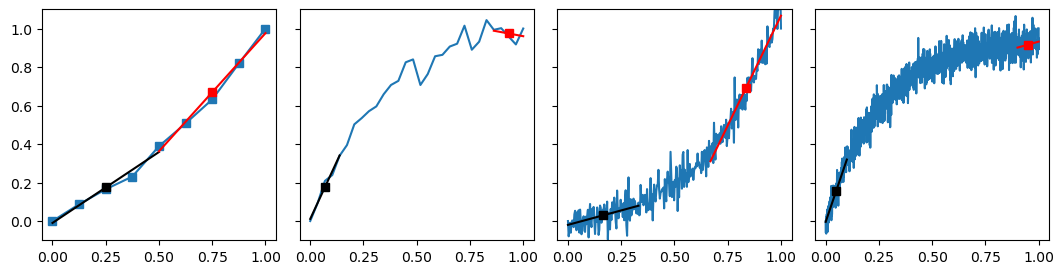

In [2]:
rng = np.random.default_rng(1)

def f(x, a, b, c):
    return a + b * np.exp(c * x)

def fn(x, a, b, c, s):
    y = f(x, a, b, c) + rng.normal(0, s, len(x))
    return (y - y[0]) / (y[-1] - y[0])

tests = [
    (3, 2, 1, 0.07, 9),
    (-1, -2, -3, 0.08, 30),
    (-3, 5, 3, 5, 300),
    (4, -2, -4, 0.1, 1200),
]

fig = plt.figure(figsize=(13, 3))
fig.subplots_adjust(wspace=0.1)
grd = fig.add_gridspec(1, 4)
for i, (a, b, c, s, n) in enumerate(tests):
    x = np.linspace(0, 1, n)
    y = fn(x, a, b, c, s)

    ax = fig.add_subplot(grd[i])
    ax.set_ylim(-0.1, 1.1)
    if i > 0:
        ax.set_yticklabels([])

    ax.plot(x, y, 's-' if n < 10 else '-')
    a0, b0, c0 = expfit.estimate_initial_single(x, y, axes=ax)

plt.show()

In this example (random seed 1), the second segment isn't ideal: due to the low signal-to-noise ratio in this part of the graph, the estimated slope is way off.
The fourth example suffers from this a little too.

Note that we have normalised the data here, causing all examples (note the different signs etc.) to look very similar

Now, we run again showing the initial guesses.

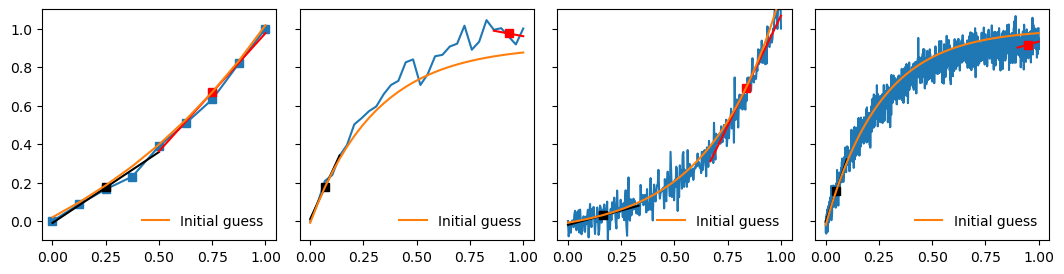

In [3]:
rng = np.random.default_rng(1)

def fn(x, a, b, c, s):
    y = f(x, a, b, c) + rng.normal(0, s, len(x))
    return (y - y[0]) / (y[-1] - y[0])

fig = plt.figure(figsize=(13, 3))
fig.subplots_adjust(wspace=0.1)
grd = fig.add_gridspec(1, 4)
for i, (a, b, c, s, n) in enumerate(tests):
    x = np.linspace(0, 1, n)
    y = fn(x, a, b, c, s)

    ax = fig.add_subplot(grd[i])
    ax.plot(x, y, 's-' if n < 10 else '-')
    a0, b0, c0 = expfit.estimate_initial_single(x, y, axes=ax)
    ax.plot(x, f(x, a0, b0, c0), label='Initial guess', zorder=10)
    ax.legend(frameon=False, loc='lower right')
    ax.set_ylim(-0.1, 1.1)
    if i > 0:
        ax.set_yticklabels([])

plt.show()

So despite the noisy $S_2$ in the 2nd panel, the initial estimate is still OK: an optimiser should easily be able to fit this.

## Fitting a single exponential

1. Transform to approximate unit square
2. Use H2 to find initial guess $a_0, b_0, c_0$
3. Minise the MSE: $\frac{1}{n}\sum \left(y_i - a - b e^{c t_i}\right)^2$
4. Detransform the obtained parameters and return

### Fitting $c$ in log-space?

Probably better conditioned. Haven't tried.

## Jacobian

Using the MSE rather than the RMSE means we have easy-to-compute jacobians and hessians.

First, we write out the MSE as $E$:
\begin{align}
   E &= \frac{1}{n} \sum \left(y_i - a - b e^{c x_i} \right)^2 \\
     &= \frac{1}{n} \sum y_i^2 + a^2 - 2 a y_i + 2 a b e^{c x_i} - 2 b y_i e^{c x_i} + b^2 e^{c x_i} \\
&\equiv \frac{1}{n} \sum y_i^2 + a^2 - 2 a y_i + 2 a b e_i - 2 b y_i e_i + b^2 e_i^2
\end{align}
where, for convenience, $e_i = e^{c x_i}$.

Then
\begin{align}
\frac{\partial E}{\partial a} &= \frac{1}{n} \sum 2 a - 2 y_i + 2 b e_i 
                              &&= \frac{2}{n} \sum a - y_i + b e_i \\
\frac{\partial E}{\partial b} &= \frac{1}{n} \sum 2 a e_i - 2 y_i e_i + 2 b e_i^2 
                              &&= \frac{2}{n} \sum (a - y_i + b e_i) e_i \\
\frac{\partial E}{\partial c} &= \frac{1}{n} \sum 2 a b x_i e_i - 2 b x_i y_i e_i + 2 b^2 x_i e_i^2
                              &&= \frac{2b}{n} \sum (a - y_i + b e_i) x_i e_i \\
\end{align}

This is good news, computationally.
In a compiled language, we could write
```
for i in ...
    e = exp(c * x[i])
    da_increment = a - y[i] + b * e
    db_increment = da_increment * e
    dc_increment = db_increment * x[i]
```

In Python/NumPy, it's faster to implement this with array operations
```
e = np.exp(c * x)                  # 2 array operations
f = a - v + b * e                  # 3
g = e * f                          # 1
da = 2 / n * np.sum(f)             # 1
db = 2 / n * np.sum(g)             # 1 
dc = 2 / n * np.sum(g * x) * b     # 2 
```
which works out as 10 array operations.

### Checking our workings

We can check against finite differences:

In [4]:
a, b, c = 5, 5, -3
n = 100
x = np.linspace(0, 1, n)
y = a + b * np.exp(c * x)

a0, b0, c0 = a + 1, b - 1, c + 1
y0 = f(x, a0, b0, c0)

def mse(x, y, a, b, c):
    return np.sum((y - a - b * np.exp(c * x))**2) / len(x)

def mse_jac(x, y, a, b, c):
    m = 1 / n
    e = np.exp(c * x)
    g = a - y + b * e
    eg = e * g
    da = 2 * m * np.sum(g)
    db = 2 * m * np.sum(eg)
    dc = 2 * m * np.sum(eg * x) * b
    return m * np.sum(g * g), da, db, dc

def mse_jac_fd(x, y, a, b, c, dp=1e-9):
    m = 1 / n
    r1 = mse(x, y, a, b, c)
    da = (mse(x, y, a + dp, b, c) - r1) / dp
    db = (mse(x, y, a, b + dp, c) - r1) / dp
    dc = (mse(x, y, a, b, c + dp) - r1) / dp
    return r1, da, db, dc

m0 = mse(x, y, a0, b0, c0)
m1, da1, db1, dc1 = mse_jac(x, y, a0, b0, c0)
m2, da2, db2, dc2 = mse_jac_fd(x, y, a0, b0, c0)

print(f'Plain mse {m0}')
print(f'  mse_jac {m1}')
print(f'  mse_fd  {m2}')
print(f'dE/da {da1}')
print(f'   fd {da2}')
print(f'dE/db {db1}')
print(f'   fd {db2}')
print(f'dE/dc {dc1}')
print(f'   fd {dc2}')

Plain mse 1.4223235997383419
  mse_jac 1.4223235997383419
  mse_fd  1.4223235997383419
dE/da 2.281170165188211
   fd 2.2811705857606057
dE/db 0.8347188315402757
   fd 0.8347191826629796
dE/dc 1.4618025059805984
   fd 1.461802900948328


And even run a plain gradient descent:

In [5]:
alpha = 0.7
a1, b1, c1 = a0, b0, c0
for i in range(1000):
    m1, da, db, dc = mse_jac(x, y, a1, b1, c1)
    a1 -= da * alpha
    b1 -= db * alpha
    c1 -= dc * alpha
        
print(i, m1)
print(f'  {a: } {a1: 6f}')
print(f'  {b: } {b1: 6f}')
print(f'  {c: } {c1: 6f}')

999 4.6560345431023555e-23
   5  5.000000
   5  5.000000
  -3 -3.000000


## Hessian

We can go a step further and find the Hessian

From $\frac{\partial E}{\partial a} = \frac{2}{n} \sum a - y_i + b e_i $
\begin{align}
\frac{\partial^2 E}{\partial a^2} 
    &= \frac{2}{n} \sum 1 = 2 \\
\frac{\partial^2 E}{\partial a \, \partial b} 
    &= \frac{2}{n} \sum e_i \\
\frac{\partial^2 E}{\partial a \, \partial c} 
    &= \frac{2b}{n} \sum x_i e_i \\
\end{align}

From $\frac{\partial E}{\partial b} = \frac{2}{n} \sum (a - y_i + b e_i) e_i $
\begin{align}
\frac{\partial^2 E}{\partial b \, \partial a} 
    &= \frac{2}{n} \sum e_i \\
\frac{\partial^2 E}{\partial b^2}
    &= \frac{2}{n} \sum (a - y_i + b e_i) e_i \\
\frac{\partial^2 E}{\partial b \, \partial c}
    &= \frac{2}{n} \sum (a - y_i + 2 b e_i) x_i e_i
\end{align}

From $\frac{\partial E}{\partial c} = \frac{2b}{n} \sum (a - y_i + b e_i) x_i e_i $
\begin{align}
\frac{\partial^2 E}{\partial c \, \partial a}
    &= \frac{2b}{n} \sum x_i e_i \\
\frac{\partial^2 E}{\partial c \, \partial b}
    &= \frac{2}{n} \sum (a - y_i + 2 b e_i) x_i e_i   \\
\frac{\partial^2 E}{\partial c^2}
    &= \frac{2b}{n} \sum (a - y_i + 2 b e_i) x_i^2 e_i \\
\end{align}

**Sanity checks**: 
\begin{align}
\frac{\partial^2 E}{\partial a \, \partial b} &= \frac{\partial^2 E}{\partial b \, \partial a}, &&
\frac{\partial^2 E}{\partial a \, \partial c} &= \frac{\partial^2 E}{\partial c \, \partial a}, &&
\frac{\partial^2 E}{\partial b \, \partial c} &= \frac{\partial^2 E}{\partial c \, \partial b} 
\end{align}

### Checking our workings

In [8]:
def mse_jac_hes(x, y, p):
    a, b, c = p
    m = 1 / n
    e = np.exp(c * x)
    f = a - y + b * e
    ef = e * f
    mse = m * np.sum(f * f)

    # Jacobian
    jac = np.array([
        2 * m * np.sum(f),
        2 * m * np.sum(ef),
        2 * m * np.sum(ef * x) * b
    ])

    # Hessian
    ex = e * x
    aex = (a - y + 2 * b * e) * ex
    hes = np.array([
        [2, 2 * m * np.sum(e), 2 * b * m * np.sum(ex)],
        [0, 2 * m * np.sum(e * e), 2 * m * np.sum(aex)],
        [0, 0, 2 * m * b * np.sum(x * aex)],
    ])
    hes[1, 0] = hes[0, 1]
    hes[2, 0] = hes[0, 2]
    hes[2, 1] = hes[1, 2]
    
    return mse, jac, hes

m1, j1, h1 = mse_jac_hes(x, y, (a0, b0, c0))

print(m1)
print(j1)
print(h1)

1.4223235997383419
[2.28117017 0.83471883 1.46180251]
[[2.         0.86740054 1.18144538]
 [0.86740054 0.49618302 0.81578101]
 [1.18144538 0.81578101 1.60402956]]


In [9]:
def mse_jac_hes_fd(x, y, p, dp=1e-6):
    a, b, c = p
    err = mse(x, y, a, b, c)
    da = lambda a, b, c: (mse(x, y, a + dp, b, c) - mse(x, y, a, b, c)) / dp
    db = lambda a, b, c: (mse(x, y, a, b + dp, c) - mse(x, y, a, b, c)) / dp
    dc = lambda a, b, c: (mse(x, y, a, b, c + dp) - mse(x, y, a, b, c)) / dp
    jac = np.array([da(a, b, c), db(a, b, c), dc(a, b, c)])
    hes = np.array([
        [(da(a + dp, b, c) - da(a, b, c)) / dp,
         (da(a, b + dp, c) - da(a, b, c)) / dp,
         (da(a, b, c + dp) - da(a, b, c)) / dp], 
        [(db(a + dp, b, c) - db(a, b, c)) / dp,
         (db(a, b + dp, c) - db(a, b, c)) / dp,
         (db(a, b, c + dp) - db(a, b, c)) / dp],
        [(dc(a + dp, b, c) - dc(a, b, c)) / dp,
         (dc(a, b + dp, c) - dc(a, b, c)) / dp,
         (dc(a, b, c + dp) - dc(a, b, c)) / dp]        
    ])
    
    return err, jac, hes

m1, j1, h1 = mse_jac_hes(x, y, (a0, b0, c0))
m2, j2, h2 = mse_jac_hes_fd(x, y, (a0, b0, c0))
print(f'Plain mse {m0}')
print(f'  mse_jac {m1}')
print(f'  mse_fd  {m2}')
print()
print(f'dE/da {j1[0]}')
print(f'   fd {j2[0]}')
print(f'dE/db {j1[1]}')
print(f'   fd {j2[1]}')
print(f'dE/dc {j1[2]}')
print(f'   fd {j2[2]}')
print()
print(h1)
print()
print(h2)

Plain mse 1.4223235997383419
  mse_jac 1.4223235997383419
  mse_fd  1.4223235997383419

dE/da 2.281170165188211
   fd 2.281171165741114
dE/db 0.8347188315402757
   fd 0.8347190805224614
dE/dc 1.4618025059805984
   fd 1.461803308400178

[[2.         0.86740054 1.18144538]
 [0.86740054 0.49618302 0.81578101]
 [1.18144538 0.81578101 1.60402956]]

[[2.00039985 0.86708418 1.18083321]
 [0.86708418 0.49515947 0.8149037 ]
 [1.18083321 0.8149037  1.60316205]]


We can test this result by bravely doing a Newton iteration:

In [10]:
p0 = np.array([a0, b0, c0], dtype=float)
m1, j1, h1 = mse_jac_hes(x, y, p0)
p1 = p0 - np.linalg.inv(h1) @ j1

print(a, b, c)
print(p0)
print(p1)

5 5 -3
[ 6.  4. -2.]
[ 2.46233735 14.47653658 -5.63385256]


In [30]:
p1 = np.array([[a0, b0, c0]], dtype=float)
print(p1)
for i in range(40):
    m1, j1, h1 = mse_jac_hes(x, y, p1[0])
    p1 -= 0.5 * np.linalg.inv(h1) @ j1
print(p1)

[[ 6.  4. -2.]]
[[ 5.  5. -3.]]


So in 40 iterations we're close enough to the true solution that NumPy's standard rounding hides the difference.

We can also have a look at the final MSE:

In [31]:
print(m1)

5.434953744588314e-23


So based on that, we would have probably stopped sooner.

### Compare Newton's method with SciPy

Default run:

In [ ]:
from scipy.optimize import minimize as fmin

def E(p):
    return np.sum((y - p[0] - p[1] * np.exp(p[2] * x))**2) / len(x)

fmin(E, p0)

It doesn't tell you, but looks like it's using BFGS by default

In [ ]:
fmin(E, p0, method='bfgs')

In [ ]:
class CachedHesJac:
    _p = None
    _mse = None
    _jac = None
    _hes = None
    def _do(self, p):
        if np.any(p != self._p):
            self._mse, self._jac, self._hes = mse_jac_hes(x, y, p)
            self._p = np.copy(p)
    def mse(self, p):
        self._do(p)
        return self._mse
    def jac(self, p):
        self._do(p)
        return self._jac
    def hes(self, p):
        self._do(p)
        return self._hes
        
chj = CachedHesJac()
fmin(chj.mse, p0, jac=chj.jac)

Remarkably, we need about 250 iterations to get to the same accuracy

In [ ]:
import timeit
p1 = np.array([[a0, b0, c0]], dtype=float)
time = timeit.default_timer()
for i in range(247):
    m1, j1, h1 = mse_jac_hes(x, y, p1[0])
    p1 -= np.linalg.inv(h1) @ j1
time = timeit.default_timer() - time
print(m1)
print(time)

In [ ]:
time = timeit.default_timer()
r = fmin(chj.mse, p0, jac=chj.jac)
time = timeit.default_timer() - time
print(time)

In [ ]:
time = timeit.default_timer()
r = fmin(chj.mse, p0, jac=chj.jac)
time = timeit.default_timer() - time
print(time)

And it's faster too.